# Example: Fast Fourier Transform Recursive Relationship (FFTRR) Algorithm for Poisson Equation on the Disk

This notebook demonstrates how to use the `fftrr_poisson` package to solve the 2D Poisson equation 
$$
\Delta u = f \quad \text{on} \quad \{ (x,y) : x^2 + y^2 \leq R^2 \}
$$
using the FFTRR method with configurable boundary conditions and quadrature rules. The true analytical solution, error analysis, and 3D visualization are included.

**Reference:**  
L. Borges and P. Daripa, "A Fast Parallel Algorithm for the Poisson Equation on a Disk," J. Comput. Phys. 169(1):151–192, 2001.

## Package Imports

In [9]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Poisson_Solver import (
    generate_grid_values,
    generate_uniform_radial,
    generate_nonuniform_radial,
    generate_uniform_azimuthal,
    generate_fixed_nonuniform_azimuthal,
    generate_nonuniform_azimuthal,
    generate_cartesian_grid_on_disk,
    trap_2d_on_disk,
    compute_error_metrics,
    plot_on_disk_with_error,
    plot_on_disk,
    poisson_solver,
    plot_grid
)




## Problem Parameters and Setup

Configure the grid, boundary conditions, and true solution for the problem.

You may modify the parameters and functions below for other problems.

In [10]:
# Quadrature rule: 1 = Trapezoidal, 2 = Simpson's
quad_rule = 1

# Boundary condition choice: 1 = Dirichlet, 2 = Neumann
bc_choice = 1


# Solution and data functions
'''u = lambda x, y: x**2 + 3 * y**3
f = lambda x, y: 2 + 18 * y
g = lambda x, y: u(x, y)'''

alpha = 5.0
u = lambda x, y: np.sin(alpha * np.pi * (x + y))
f = lambda x, y: -2 * alpha**2 * np.pi**2 * np.sin(alpha * np.pi * (x + y))
g = lambda x, y: u(x, y)    # Dirichlet boundary

# Discretization parameters
M = 64  # Number of radial points
N = 64  # Number of angular points
R = 1.0 # Disk radius

# Radial mesh type: 1 = uniform, 0 = non-uniform
rad_unif = 1

# Azimuthal mesh type: 2 = uniform, 1 = non-uniform with same mesh along radii, 0 completely nonuniform 
azu_unif = 2

## Mesh Generation

This section sets up the polar mesh, convert it to Cartesian coordinates, and evaluates the data on the grid.

In [11]:
# Choose the radial mesh.
if rad_unif == 1:
    iRadius = generate_uniform_radial(M,R)
elif rad_unif == 0:
    iRadius = generate_nonuniform_radial(M, R)
else:
    raise ValueError('Incorrect index for "rad_unif"')


# Choose the azimuthal mesh.
if azu_unif == 2:
    # uniform, shared along radii: shape (N,)
    iAngle = generate_uniform_azimuthal(N)
elif azu_unif == 1:
    # nonuniform, shared along radii: shape (N,)
    iAngle = generate_fixed_nonuniform_azimuthal(N, kind="rand")
elif azu_unif == 0:
    # fully nonuniform: different azimuthal mesh per radius, shape (N, M)
    iAngle = generate_nonuniform_azimuthal(N, M, kind="rand")
else:
    raise ValueError("Incorrect index for 'azu_unif'")


# Polar-to-Cartesian coordinates for plotting and evaluation
x_coord, y_coord = generate_cartesian_grid_on_disk(iAngle, iRadius)

# Evaluate source, boundary, and true solution on appropriate mesh
f_values = generate_grid_values(f, x_coord, y_coord)
g_values = generate_grid_values(g, x_coord[:, M - 1], y_coord[:, M - 1])
u_true   = generate_grid_values(u, x_coord, y_coord)




## Specialized Inputs for Neumann Problem
Provide the mean Fourier mode for Neumann BC, otherwise leave empty.

In [12]:
if bc_choice == 2:
    # average over angles (axis 0), shape (M,)
    u_fourier_0 = u_true.mean(axis=0)
else:
    u_fourier_0 = np.array([])


## Solve the Poisson Equation
Run the main algorithm and compute the solution on the mesh.

In [13]:
## Solve the Poisson Equation
# Run the main algorithm and compute the solution on the mesh.

# Set this flag per experiment (only used when azu_unif in {1, 0} and you have
# implemented those analysis paths):
#   False → NUFFT + block CG (fast, approximate)
#   True  → direct NUDFT (dense, reference)
use_nudft_angular = True   # change to True to force NUDFT

if azu_unif in (2, 1, 0):
    u_approx = poisson_solver(
        f_values, g_values, u_fourier_0,
        N, M, iRadius, iAngle, R,
        quad_rule, bc_choice,
        rad_unif, azu_unif,
        use_nudft_angular=use_nudft_angular,
        maxiter_nufft=50,
        tol_nufft=1e-8,
        use_gpu=False
    )
else:
    raise ValueError('Incorrect index for "azu_unif"')


## Error Analysis
Compute absolute and relative L∞ and L₂ errors between numerical and true solution.

In [14]:
L_inf_error, L_inf_error_rel, L2_error, L2_error_rel = compute_error_metrics(
    u_approx, u_true, iRadius, iAngle
)

print(f"L∞ error:     {L_inf_error:.3e}")
print(f"Rel L∞ error: {L_inf_error_rel:.3e}")
print(f"L2 error:     {L2_error:.3e}")
print(f"Rel L2 error: {L2_error_rel:.3e}")




L∞ error:     1.373e-02
Rel L∞ error: 1.373e-02
L2 error:     1.272e-02
Rel L2 error: 1.014e-02


**Interpretation**:  
A small relative error (close to 0) confirms the solver works correctly.  
For coarse grids or more challenging problems, try increasing `M`, `N`, or experiment with different `quad_rule` and `bc_choice`.

# Delete later

64by64 Nonuniform azimuthal type 1:
L∞ error:     2.993e-04
Rel L∞ error: 9.996e-05
L2 error:     3.683e-05
Rel L2 error: 1.764e-05


L∞ error:     2.993e-04
Rel L∞ error: 9.978e-05
L2 error:     5.254e-05
Rel L2 error: 2.017e-05



## Visualization
View the true solution, the computed approximation, and the pointwise error.

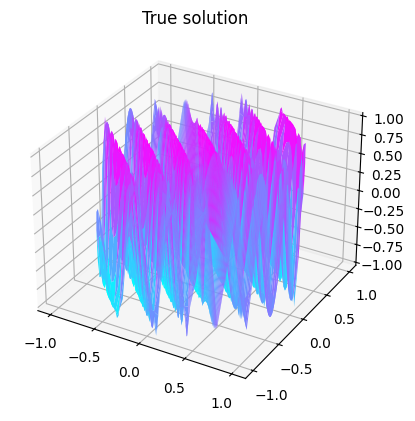

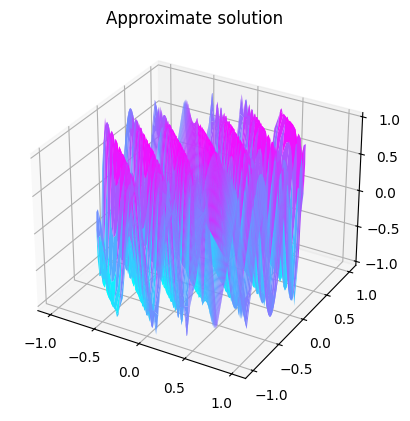

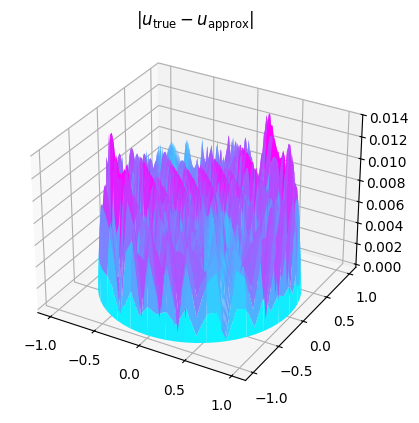

In [15]:
plot_on_disk_with_error(x_coord, y_coord, u_approx, u_true)
# Uncomment below to visualize the approximation only (if no analytical solution)
# plot_on_disk(x_coord, y_coord, u_approx)

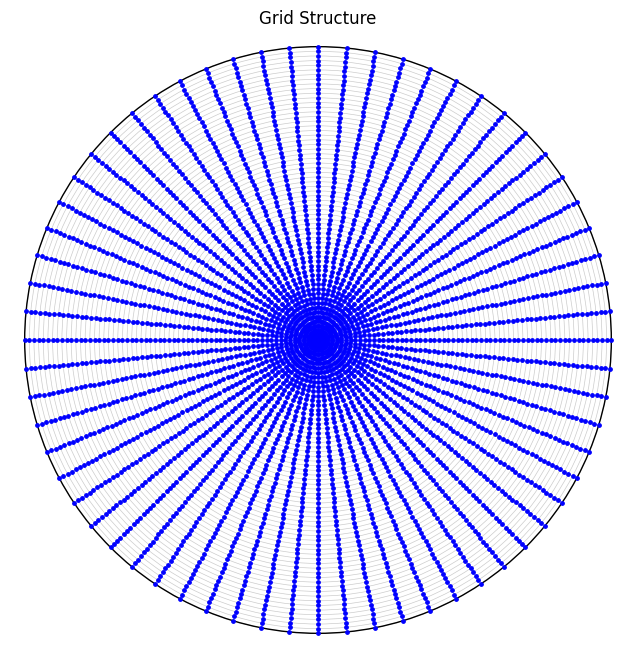

In [16]:
# Visualize the grid structure
fig, ax = plt.subplots(figsize=(8, 8))
plot_grid(ax, iAngle, iRadius, R, "Grid Structure", "blue")
plt.show()